In [105]:
import torch
import os

import sys
sys.path.append('/root/dl-hse-part2/hw1/VSSD/classification')

import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.models as models

from models.mamba2 import Backbone_VMAMBA2
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image

In [106]:
class BreastDataset(Dataset):
    def __init__(self, root_dir, transform=None, split='train', test_size=0.2):
        self.data = []
        self.labels = []
        self.classes = ['benign', 'malignant', 'normal']
        self.class_to_idx = {'benign': 0, 'malignant': 1, 'normal': 2}
        
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                files = os.listdir(class_path)
                image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg')) 
                             and 'mask' not in f.lower()]
                
                for img_name in image_files:
                    img_path = os.path.join(class_path, img_name)
                    self.data.append(img_path)
                    self.labels.append(self.class_to_idx[class_name])
                
                print(f"Class '{class_name}': {len(image_files)} images")
        
        
        print(f"Total images collected: {len(self.data)}")
        
        indices = np.arange(len(self.data))
        train_idx, val_idx = train_test_split(
            indices, 
            test_size=test_size, 
            stratify=self.labels,
            random_state=42
        )
        
        if split == 'train':
            self.data = [self.data[i] for i in train_idx]
            self.labels = [self.labels[i] for i in train_idx]
        else:
            self.data = [self.data[i] for i in val_idx]
            self.labels = [self.labels[i] for i in val_idx]
        
        print(f"{split} set size: {len(self.data)}")
        
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [136]:
class SimpleVSSDClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        self.backbone = Backbone_VMAMBA2(
            embed_dim=96,
            depths=[2, 2, 8, 2],
            num_heads=[4, 4, 8, 16],
            out_indices=(0, 1, 2, 3),  # до этого был только последний уровень
            drop_path_rate=0.2,
            mlp_ratio=3.0,
            use_checkpoint=False,
            simple_patch_embed=True,
            simple_downsample=True,
            rmt_downsample=False,
            rmt_patch_embed=False,
            linear_attn_duality=True,
            ssd_positive_da=True,
            exp_da=True,
            rope=True
        )
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # self.classifier = nn.Sequential(
        #     nn.Linear(768, 256),  # Для embed_dim=96, выход 768
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(256, num_classes)
        # )
        
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),  # Для embed_dim=96, выход 768
            nn.BatchNorm1d(256),
            nn.ReLU(),
           
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(64, num_classes)
           )
        
    def forward(self, x):
        backbone_outputs = self.backbone(x)

        features = backbone_outputs[-1] # важен только последний уровень
        
        pooled = self.global_pool(features)
        pooled = pooled.flatten(1)
        
        return self.classifier(pooled)

In [137]:
class ResNetBaseline(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        self.model = models.resnet50(pretrained=pretrained)
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

In [138]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if batch_idx % 5 == 0:
            print(f'Epoch: {epoch} | Batch: {batch_idx}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f} | Acc: {100.*correct/total:.2f}%')
    
    return total_loss/len(train_loader), 100.*correct/total

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return val_loss/len(val_loader), 100.*correct/total


In [139]:
def run_experiment(model_type='vssd', data_dir=None, epochs=10, batch_size=8):
    data_dir = '/root/dl-hse-part2/hw1/breast_dataset/Dataset_BUSI_with_GT'
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    possible_paths = [
        'breast_dataset/Dataset_BUSI_with_GT',
        'Dataset_BUSI_with_GT',
        '../Dataset_BUSI_with_GT',
        './Dataset_BUSI_with_GT',
        '/content/Dataset_BUSI_with_GT'
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            data_dir = path
            print(f"Found dataset at: {data_dir}")
            break
    
    print("\nCreating datasets...")
    
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10), 
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225])
    ])
    
    train_dataset = BreastDataset(data_dir, transform=train_transform, split='train')
    val_dataset = BreastDataset(data_dir, transform=val_transform, split='val')
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    
    # Создаем модель
    if model_type == 'vssd':
        print("\nInitializing VSSD model...")
        model = SimpleVSSDClassifier(num_classes=3).to(device)
    else:
        print("\nInitializing ResNet model...")
        model = ResNetBaseline(num_classes=3).to(device)
    
    # Подсчет параметров
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    # Оптимизатор и функция потерь
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    # Обучение
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    print(f"\nStarting training for {epochs} epochs...")
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"\nEpoch {epoch}/{epochs} Summary:")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print("-" * 50)
    
    return {
        'model_type': model_type,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'final_train_acc': train_accs[-1],
        'final_val_acc': val_accs[-1],
        'best_val_acc': max(val_accs)
    }

BREAST CANCER CLASSIFICATION WITH VSSD
Using device: cuda:0
Found dataset at: breast_dataset/Dataset_BUSI_with_GT

Creating datasets...
Class 'benign': 437 images
Class 'malignant': 210 images
Class 'normal': 133 images
Total images collected: 780
train set size: 624
Class 'benign': 437 images
Class 'malignant': 210 images
Class 'normal': 133 images
Total images collected: 780
val set size: 156
Train samples: 624
Val samples: 156

Initializing VSSD model...
Total parameters: 34,129,875

Starting training for 15 epochs...
Epoch: 1 | Batch: 0/78 | Loss: 1.2913 | Acc: 25.00%
Epoch: 1 | Batch: 5/78 | Loss: 1.1800 | Acc: 25.00%
Epoch: 1 | Batch: 10/78 | Loss: 1.1972 | Acc: 29.55%
Epoch: 1 | Batch: 15/78 | Loss: 1.1787 | Acc: 28.12%
Epoch: 1 | Batch: 20/78 | Loss: 1.2459 | Acc: 26.79%
Epoch: 1 | Batch: 25/78 | Loss: 1.2110 | Acc: 26.44%
Epoch: 1 | Batch: 30/78 | Loss: 1.1257 | Acc: 27.02%
Epoch: 1 | Batch: 35/78 | Loss: 1.1497 | Acc: 26.74%
Epoch: 1 | Batch: 40/78 | Loss: 1.0099 | Acc: 28.66

/root/miniconda3/envs/project/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/project/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Total parameters: 23,514,179

Starting training for 15 epochs...
Epoch: 1 | Batch: 0/78 | Loss: 1.2229 | Acc: 25.00%
Epoch: 1 | Batch: 5/78 | Loss: 1.0628 | Acc: 37.50%
Epoch: 1 | Batch: 10/78 | Loss: 1.0678 | Acc: 46.59%
Epoch: 1 | Batch: 15/78 | Loss: 0.8380 | Acc: 48.44%
Epoch: 1 | Batch: 20/78 | Loss: 0.6887 | Acc: 53.57%
Epoch: 1 | Batch: 25/78 | Loss: 0.7936 | Acc: 56.25%
Epoch: 1 | Batch: 30/78 | Loss: 0.8824 | Acc: 58.06%
Epoch: 1 | Batch: 35/78 | Loss: 0.7941 | Acc: 58.33%
Epoch: 1 | Batch: 40/78 | Loss: 0.6137 | Acc: 59.76%
Epoch: 1 | Batch: 45/78 | Loss: 0.8919 | Acc: 60.60%
Epoch: 1 | Batch: 50/78 | Loss: 0.9380 | Acc: 60.29%
Epoch: 1 | Batch: 55/78 | Loss: 0.9579 | Acc: 62.28%
Epoch: 1 | Batch: 60/78 | Loss: 0.5880 | Acc: 63.32%
Epoch: 1 | Batch: 65/78 | Loss: 0.6810 | Acc: 63.45%
Epoch: 1 | Batch: 70/78 | Loss: 0.2593 | Acc: 64.08%
Epoch: 1 | Batch: 75/78 | Loss: 0.1732 | Acc: 65.46%

Epoch 1/15 Summary:
Train Loss: 0.7355, Train Acc: 65.71%
Val Loss: 0.5462, Val Acc: 83.

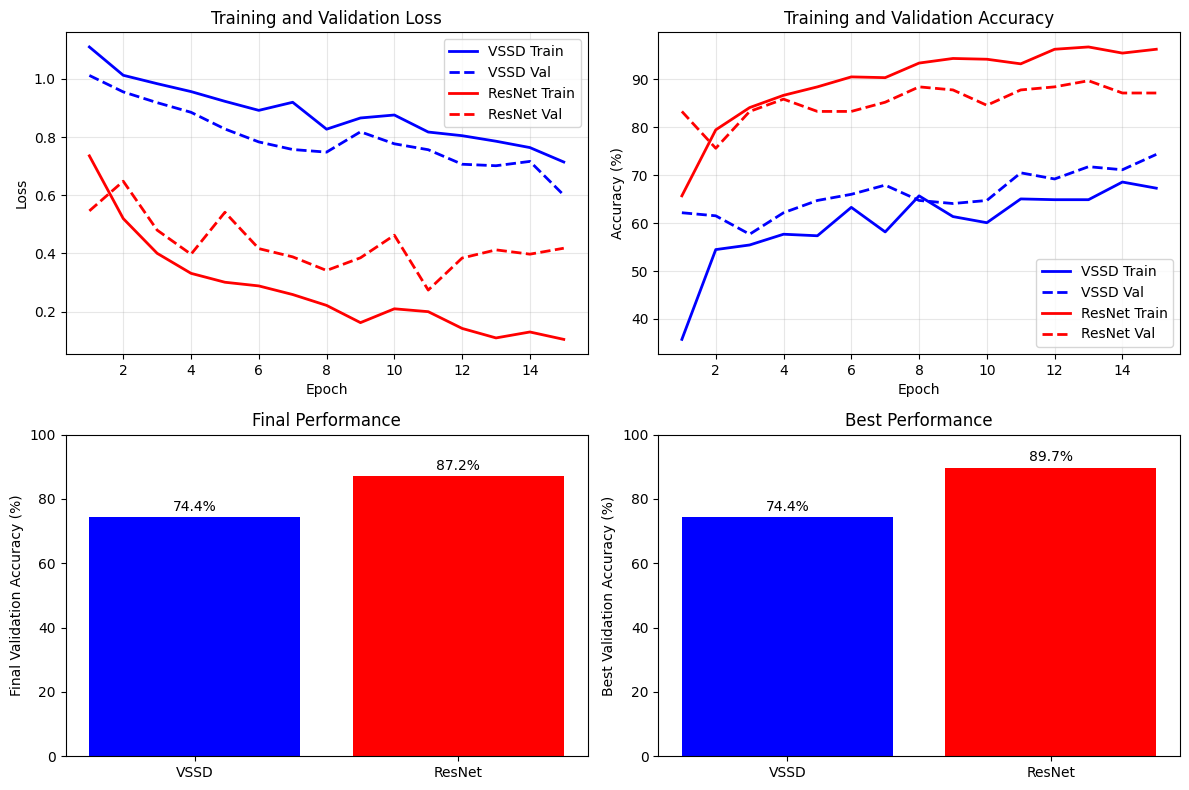


FINAL COMPARISON
VSSD - Best Val Accuracy: 74.36%
ResNet - Best Val Accuracy: 89.74%
Improvement: -15.38%


In [140]:
def plot_results(vssd_results, resnet_results):
    """Визуализация результатов"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    epochs = range(1, len(vssd_results['train_losses']) + 1)
    
    # Loss кривые
    axes[0, 0].plot(epochs, vssd_results['train_losses'], label='VSSD Train', color='blue', linewidth=2)
    axes[0, 0].plot(epochs, vssd_results['val_losses'], label='VSSD Val', color='blue', linestyle='--', linewidth=2)
    axes[0, 0].plot(epochs, resnet_results['train_losses'], label='ResNet Train', color='red', linewidth=2)
    axes[0, 0].plot(epochs, resnet_results['val_losses'], label='ResNet Val', color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy кривые
    axes[0, 1].plot(epochs, vssd_results['train_accs'], label='VSSD Train', color='blue', linewidth=2)
    axes[0, 1].plot(epochs, vssd_results['val_accs'], label='VSSD Val', color='blue', linestyle='--', linewidth=2)
    axes[0, 1].plot(epochs, resnet_results['train_accs'], label='ResNet Train', color='red', linewidth=2)
    axes[0, 1].plot(epochs, resnet_results['val_accs'], label='ResNet Val', color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Final accuracy comparison
    models = ['VSSD', 'ResNet']
    final_accs = [vssd_results['final_val_acc'], resnet_results['final_val_acc']]
    
    bars = axes[1, 0].bar(models, final_accs, color=['blue', 'red'])
    axes[1, 0].set_ylabel('Final Validation Accuracy (%)')
    axes[1, 0].set_title('Final Performance')
    axes[1, 0].set_ylim([0, 100])
    
    for bar, acc in zip(bars, final_accs):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.1f}%', ha='center', va='bottom')
    
    # Best accuracy comparison
    best_accs = [vssd_results['best_val_acc'], resnet_results['best_val_acc']]
    
    bars = axes[1, 1].bar(models, best_accs, color=['blue', 'red'])
    axes[1, 1].set_ylabel('Best Validation Accuracy (%)')
    axes[1, 1].set_title('Best Performance')
    axes[1, 1].set_ylim([0, 100])
    
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    print("=" * 60)
    print("BREAST CANCER CLASSIFICATION WITH VSSD")
    print("=" * 60)
    
    vssd_full = run_experiment(model_type='vssd', epochs=15, batch_size=8)  
    print("\n" + "=" * 60)
    print("FULL TRAINING - RESNET (15 epochs)")
    print("=" * 60)
    resnet_full = run_experiment(model_type='resnet', epochs=15, batch_size=8)
    
    # Визуализация
    print("\n" + "=" * 60)
    print("GENERATING COMPARISON PLOTS")
    print("=" * 60)
    plot_results(vssd_full, resnet_full)
    
    # Вывод результатов
    print("\n" + "=" * 60)
    print("FINAL COMPARISON")
    print("=" * 60)
    print(f"VSSD - Best Val Accuracy: {vssd_full['best_val_acc']:.2f}%")
    print(f"ResNet - Best Val Accuracy: {resnet_full['best_val_acc']:.2f}%")
    print(f"Improvement: {(vssd_full['best_val_acc'] - resnet_full['best_val_acc']):.2f}%")